In [1]:
print("""COE 311K - Midterm Project
U.S. GDP Growth Rate Analysis Using Least Squares, Polynomial Fitting, and Cubic Splines

Author: Ramaakshay Mallireddy
Due Date: 03/31/2026 11:59 PM

This script implements three curve-fitting methods from scratch:
- Natural cubic spline interpolation
- Degree-4 polynomial fitting via normal equations
- Linear least squares regression""")

COE 311K - Midterm Project
U.S. GDP Growth Rate Analysis Using Least Squares, Polynomial Fitting, and Cubic Splines

Author: Ramaakshay Mallireddy
Due Date: 03/31/2026 11:59 PM

This script implements three curve-fitting methods from scratch:
- Natural cubic spline interpolation
- Degree-4 polynomial fitting via normal equations
- Linear least squares regression


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 20 selected quarters (indices) and corresponding GDP growth rates
X_DATA = np.array([
     1,  5,  9, 13, 17, 19, 22, 25,
    27, 28, 29, 33, 37, 41, 42, 43,
    45, 49, 54, 56
], dtype=float) 


Y_DATA = np.array([
    1.7,  0.1,  2.3,  2.7,
    1.7,  5.0,  3.0,  1.5,
    3.5,  1.8,  1.3,  2.5,
    3.1, -5.1,-28.1, 33.8,
    6.3, -1.6,  2.4,  3.3
])

# Quarters to exclude from linear fit (COVID-19 affected period)
COVID_INDICES = {41, 42, 43, 44, 45}

# Full range of quarters (1 to 56) for evaluation
X_FULL = np.arange(1, 57, dtype=float)

In [4]:
#Cubic Spline
def setup_tridiagonal_matrix(x, y):
    """
    Build the tridiagonal system for natural cubic spline.
    
    Parameters:
        x : array of knot positions (length n)
        y : array of function values at knots (length n)
    
    Returns:
        A : sub-diagonal elements (length n-2)
        B : main diagonal elements (length n-2)
        C : super-diagonal elements (length n-2)
        D : right-hand side vector (length n-2)
    """
    n = len(x)
    h = np.diff(x) # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i - 1] # Subdiagonal
        B[i - 1] = 2 * (h[i-1] + h[i]) # Main diagonal
        C[i - 1] = h[i] # Superdiagonal
        D[i - 1] = 6 * ((y[i+1]-y[i])/h[i] - (y[i]-y[i-1])/h[i-1]) # Right-hand side vector
    return A, B, C, D

def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

def evaluate_spline(x_data, y_data, M, x_query):
    """
    Evaluate the natural cubic spline at given query points.
    
    Parameters:
        x_data : knot positions (length n)
        y_data : function values at knots (length n)
        M      : second derivatives at knots (length n); M[0]=M[-1]=0 for natural spline
        x_query: points where the spline is evaluated (scalar or array)
    
    Returns:
        S : spline values at x_query (same shape as x_query)
    """
    n = len(x_data)
    h = np.diff(x_data) # step sizes
    
    i = np.searchsorted(x_data, x_query, side='right') - 1
    i = np.clip(i, 0, n - 2) # find interval
    
    hi = h[i]
    dx_left = x_query - x_data[i] # (x - xᵢ)
    dx_right = x_data[i+1] - x_query # (xᵢ₊₁ - x)
    
    S = (
        (M[i] / (6*hi)) * dx_right**3 + # Term 1
        (M[i+1] / (6*hi)) * dx_left**3 + # Term 2
        (y_data[i] /hi - M[i] *hi/6) * dx_right + # Term 3
        (y_data[i+1] /hi - M[i+1] *hi/6) * dx_left # Term 4
    )
    return S

def build_spline_second_deriv(x, y):
    """
    Build the second derivatives for a natural cubic spline.
    
    Parameters:
        x : knot positions (length n)
        y : function values at knots (length n)
    
    Returns:
        M : second derivatives at knots (length n), with M[0]=M[-1]=0
    """
    A, B, C, D = setup_tridiagonal_matrix(x, y)
    M_interior = thomas_algorithm(A, B, C, D)
    M = np.concatenate([[0.0], M_interior, [0.0]])  # natural BC: M[0]=M[-1]=0
    return M

In [5]:
#Least Squares
def least_squares(x, y):
    """
    Compute the slope and intercept for a linear least squares fit.
    Formula: y = m*x + b
    
    Parameters:
        x : independent variable array
        y : dependent variable array
    
    Returns:
        m : slope
        b : intercept
    """
    n = len(x)
    m = (n * np.sum(x * y) - np.sum(x) * np.sum(y)) / (n * np.sum(x**2) - np.sum(x)**2)
    b = (np.sum(y) - m * np.sum(x)) / n
    return m, b

In [6]:
#Polynomial Fit
def least_squares_poly(V, y):
    """
    Solve the least squares polynomial system using normal equations and Gaussian elimination.
    Solves: (V^T V) β = V^T y
    
    Parameters:
        V : Vandermonde matrix (size n x (degree+1))
        y : target values (length n)
    
    Returns:
        coeffs : polynomial coefficients (length degree+1), highest degree first
    """
    A = V.T @ V
    b = V.T @ y
 
    n = len(b)
    M = np.hstack([A.astype(float), b.reshape(-1, 1).astype(float)])
 
    # Forward elimination with partial pivoting
    for col in range(n):
        pivot = np.argmax(np.abs(M[col:, col])) + col
        M[[col, pivot]] = M[[pivot, col]]
        for row in range(col + 1, n):
            factor = M[row, col] / M[col, col]
            M[row, col:] -= factor * M[col, col:]
 
    # Back-substitution
    coeffs = np.zeros(n)
    for i in range(n - 1, -1, -1):
        coeffs[i] = (M[i, n] - np.dot(M[i, i+1:n], coeffs[i+1:n])) / M[i, i]
 
    return coeffs

def fit_polynomial(X, Y, degree):
    """
    Fit a polynomial of specified degree to data using least squares.
    
    Parameters:
        X : independent variable array
        Y : dependent variable array
        degree : polynomial degree
    
    Returns:
        coeffs : polynomial coefficients (highest degree first)
        Y_pred : predicted values at X
    """
    # Columns: [x^d, x^(d-1), ..., x^1, x^0]
    V = np.vander(X, degree + 1)
    coeffs = least_squares_poly(V, Y)
    Y_pred = V @ coeffs
    return coeffs, Y_pred

In [7]:
def metrics(y_true, y_pred):
    """
    Compute RMSE and R².
    
    Parameters:
        y_true : ground truth values
        y_pred : predicted values
    
    Returns:
        rmse : root mean square error
        r2   : coefficient of determination
    """
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot
    return rmse, r2

In [8]:
def fit_linear_no_covid(x_all, y_all):
    """
    Perform linear regression on data excluding the COVID quarters (41-45).
    
    Parameters:
        x_all : full independent variable array
        y_all : full dependent variable array
    
    Returns:
        m : slope of linear fit
        b : intercept
        x_filtered : x values used in the fit (COVID excluded)
        y_filtered : corresponding y values
    """
    mask = ~np.isin(x_all, list(COVID_INDICES)) #Got from Claude, asked for easy one line way to remove specific values
    x = x_all[mask]
    y = y_all[mask]
    m, b = least_squares(x, y)
    return m, b, x, y

In [9]:
#Part A

M = build_spline_second_deriv(X_DATA, Y_DATA)

# Wrote out all prints then used Claude to format it properly and appealling to the eye

print("=== Part A1: Spline System ===")
n = len(X_DATA)
print(f"  Knots: {n}, Intervals: {n-1}, Interior M unknowns: {n-2}")
print()

print("--- System of Equations ---")
print(f"  Total unknowns: {n} second derivatives M[0], M[1], ..., M[{n-1}]")
print(f"  Each cubic piece S_i(x) on [x_i, x_{{i+1}}] is fully determined")
print(f"  by M[i] and M[i+1] via the standard cubic Hermite form.")
print()

print("--- Continuity Conditions at Each Interior Knot ---")
print(f"  At each interior knot x_i (i = 1, ..., {n-2}), three conditions hold:")
print("    C0 — Value continuity:      S_{i-1}(x_i) = S_i(x_i) = y_i")
print("                                (guaranteed by construction of each piece)")
print("    C1 — First deriv continuity: S'_{i-1}(x_i) = S'_i(x_i)")
print("                                (gives 1 equation per interior knot)")
print("    C2 — Second deriv continuity: S''_{i-1}(x_i) = S''_i(x_i) = M[i]")
print("                                (satisfied by sharing M[i] across pieces)")
print(f"  => {n-2} C1 equations form the tridiagonal linear system for M[1]...M[{n-2}]")
print()

print("--- Natural Spline Boundary Conditions ---")
print("  A 'natural' spline sets the second derivative to zero at both endpoints:")
print("    M[0]   = S''(x_0) = 0   (no curvature at left endpoint)")
print(f"    M[{n-1}] = S''(x_{n-1}) = 0   (no curvature at right endpoint)")
print("  Physically: the spline behaves like a straight line beyond the data range.")
print("  These 2 BCs reduce the unknowns from n to n-2 interior values,")
print("  yielding a (n-2) x (n-2) symmetric tridiagonal system.") 
print()

print("--- Verification ---")
print(f"  Natural BC enforced:  M[0] = {M[0]:.2e},  M[-1] = {M[-1]:.2e}")
max_err = np.max(np.abs(evaluate_spline(X_DATA, Y_DATA, M, X_DATA) - Y_DATA))
print(f"  Max interpolation error at knots: {max_err:.2e}  (should be ~machine epsilon)")

Y_spline = evaluate_spline(X_DATA, Y_DATA, M, X_FULL)
print("\n=== Part A2: Spline evaluated at all 56 quarters ===")
print("  Visually smooth everywhere except near COVID quarters (42-43)")
print("  Large oscillations near 2020 Q2 (-28.1) and Q3 (33.8) are expected the spline must pass through these exact extreme \nvalues")

print("\n=== Part A3: Runge Phenomenon / COVID outliers ===")
print("  The -28.1 and 33.8 values force extreme curvature in neighbouring intervals.")
print("  This is the Runge phenomenon: exact interpolation through outliers creates wild oscillations in nearby regions.")
print("  Smoothing splines or weighted least squares would be preferable they allow slight misfit at outliers in exchange for a \nmuch smoother curve.")


=== Part A1: Spline System ===
  Knots: 20, Intervals: 19, Interior M unknowns: 18

--- System of Equations ---
  Total unknowns: 20 second derivatives M[0], M[1], ..., M[19]
  Each cubic piece S_i(x) on [x_i, x_{i+1}] is fully determined
  by M[i] and M[i+1] via the standard cubic Hermite form.

--- Continuity Conditions at Each Interior Knot ---
  At each interior knot x_i (i = 1, ..., 18), three conditions hold:
    C0 — Value continuity:      S_{i-1}(x_i) = S_i(x_i) = y_i
                                (guaranteed by construction of each piece)
    C1 — First deriv continuity: S'_{i-1}(x_i) = S'_i(x_i)
                                (gives 1 equation per interior knot)
    C2 — Second deriv continuity: S''_{i-1}(x_i) = S''_i(x_i) = M[i]
                                (satisfied by sharing M[i] across pieces)
  => 18 C1 equations form the tridiagonal linear system for M[1]...M[18]

--- Natural Spline Boundary Conditions ---
  A 'natural' spline sets the second derivative to zero 

In [10]:
#PART B
coeffs4, Y_poly4_data = fit_polynomial(X_DATA, Y_DATA, 4)
Y_poly4_full = np.vander(X_FULL, 5) @ coeffs4
rmse4, r2_4 = metrics(Y_DATA, Y_poly4_data)
 
print("\n=== Part B1: Degree-4 Polynomial ===")
print(f"  RMSE: {rmse4:.4f}  |  R²: {r2_4:.4f}")
print("  The spline reproduces every data point exactly (interpolation).")
print("  The polynomial minimises overall error but misses extreme points (approximation).")
print("  Trade-off: spline is more accurate locally; polynomial is smoother globally.")

slope, intercept, x_nc, y_nc = fit_linear_no_covid(X_DATA, Y_DATA)
Y_linear = slope * X_FULL + intercept
rmse_lin, r2_lin = metrics(y_nc, slope * x_nc + intercept)
 
print("\n=== Part B2: Linear Fit (excluding COVID) ===")
print(f"  Slope:     {slope:.5f} % per quarter  (~{slope*4:.4f} % per year)")
print(f"  Intercept: {intercept:.4f} %")
print(f"  RMSE: {rmse_lin:.4f}  |  R²: {r2_lin:.4f}")
print("  Near-zero slope suggests no strong linear trend in GDP growth.")
print("  A linear model assumes constant steady growth which is unrealistic.")


=== Part B1: Degree-4 Polynomial ===
  RMSE: 10.0314  |  R²: 0.0035
  The spline reproduces every data point exactly (interpolation).
  The polynomial minimises overall error but misses extreme points (approximation).
  Trade-off: spline is more accurate locally; polynomial is smoother globally.

=== Part B2: Linear Fit (excluding COVID) ===
  Slope:     -0.00191 % per quarter  (~-0.0076 % per year)
  Intercept: 2.1943 %
  RMSE: 1.4432  |  R²: 0.0004
  Near-zero slope suggests no strong linear trend in GDP growth.
  A linear model assumes constant steady growth which is unrealistic.


In [11]:
#PART C
print("\n=== Part C: ===")
print("For interpolation between known data points, the cubic spline is the better choice.\n")
print("Smoothness:")
print("The spline guarantees continuity (smooth curve, slope, and curvature) at every knot.")
print("A degree-4 polynomial can swing wildly across the full range to fit a few points, which is economically unrealistic.\n")

print("Accuracy:")
print("The spline passes exactly through every known data point, so any estimate between two quarters is consistent with both.")
print("The polynomial least squares fit doesn't pass through every point, it minimises overall error, so the local estimate may not honour the surrounding observations.\n")

print("Sensitivity to outliers:")
print("The spline is locally contained, so an outlier or shock in 2020 doesn't distort an estimate in 2015. The polynomial spreads the influence of outliers globally, corrupting estimates. The only limitation is that quarters near the COVID-period data exhibit Runge-like oscillations in the spline, thus, in these regions, a smoothing spline would be more appropriate.")
print("\nOverall the cubic spline is more trustworthy for a policymaker doing local interpolation on stable periods of the data.")


=== Part C: ===
For interpolation between known data points, the cubic spline is the better choice.

Smoothness:
The spline guarantees continuity (smooth curve, slope, and curvature) at every knot.
A degree-4 polynomial can swing wildly across the full range to fit a few points, which is economically unrealistic.

Accuracy:
The spline passes exactly through every known data point, so any estimate between two quarters is consistent with both.
The polynomial least squares fit doesn't pass through every point, it minimises overall error, so the local estimate may not honour the surrounding observations.

Sensitivity to outliers:
The spline is locally contained, so an outlier or shock in 2020 doesn't distort an estimate in 2015. The polynomial spreads the influence of outliers globally, corrupting estimates. The only limitation is that quarters near the COVID-period data exhibit Runge-like oscillations in the spline, thus, in these regions, a smoothing spline would be more appropriate.

O

In [12]:
print("Big O Notation Section:\n")
print("Big-O notation describes how an algorithm’s runtime scales with input size, allowing us to determine the efficiency of your algorithm. In this project, linear least squares runs in O(n) time and is the fastest, making it ideal for overall trend analysis but not for detailed interpolation. Polynomial fitting has complexity O(n^4) (for a fixed degree of 4) and it suffers from numerical instability due to poor conditioning. Cubic spline interpolation has O(n) runtime and solve time using a tridiagonal system (via the Thomas algorithm), with O(log n) evaluation, making it both scalable and numerically stable. While  all methods are trivial for small datasets, the spline stands out for larger datasets because it maintains linear complexity and stability, reinforcing its suitability for interpolation, while linear regression remains best for simple, interpretable trends.")

Big O Notation Section:

Big-O notation describes how an algorithm’s runtime scales with input size, allowing us to determine the efficiency of your algorithm. In this project, linear least squares runs in O(n) time and is the fastest, making it ideal for overall trend analysis but not for detailed interpolation. Polynomial fitting has complexity O(n^4) (for a fixed degree of 4) and it suffers from numerical instability due to poor conditioning. Cubic spline interpolation has O(n) runtime and solve time using a tridiagonal system (via the Thomas algorithm), with O(log n) evaluation, making it both scalable and numerically stable. While  all methods are trivial for small datasets, the spline stands out for larger datasets because it maintains linear complexity and stability, reinforcing its suitability for interpolation, while linear regression remains best for simple, interpretable trends.


In [13]:
resid_poly = Y_DATA - Y_poly4_data
resid_lin  = y_nc - (slope * x_nc + intercept)
Y_lin_full = Y_linear

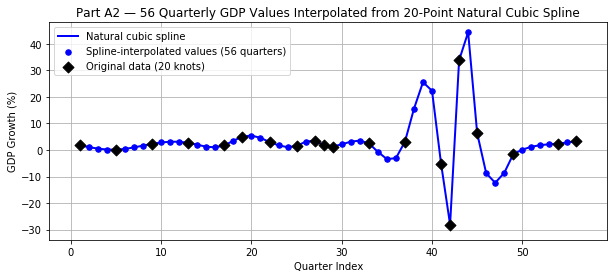

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(X_FULL, Y_spline, color='blue', s=30, zorder=4, label='Spline-interpolated values (56 quarters)')
ax.scatter(X_DATA, Y_DATA, color='black', s=60, zorder=5, marker='D', label='Original data (20 knots)')
ax.plot(X_FULL, Y_spline, color='blue', lw=2, label='Natural cubic spline')
ax.set_title('Part A2 — 56 Quarterly GDP Values Interpolated from 20-Point Natural Cubic Spline')
ax.set_xlabel('Quarter Index')
ax.set_ylabel('GDP Growth (%)')
ax.legend()
ax.grid(True)
plt.show()

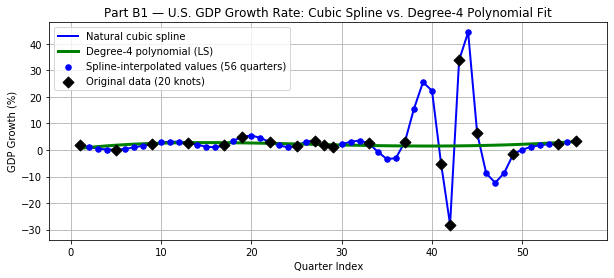

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(X_FULL, Y_spline, color='blue', s=30, zorder=4, label='Spline-interpolated values (56 quarters)')
ax.scatter(X_DATA, Y_DATA, color='black', s=60, zorder=5, marker='D', label='Original data (20 knots)')
ax.plot(X_FULL, Y_spline, color='blue', lw=2, label='Natural cubic spline')
ax.plot(X_FULL, Y_poly4_full, color='green', lw = "3", label='Degree-4 polynomial (LS)')
ax.set_title('Part B1 — U.S. GDP Growth Rate: Cubic Spline vs. Degree-4 Polynomial Fit')
ax.set_xlabel('Quarter Index')
ax.set_ylabel('GDP Growth (%)')
ax.legend()
ax.grid(True)
plt.show()

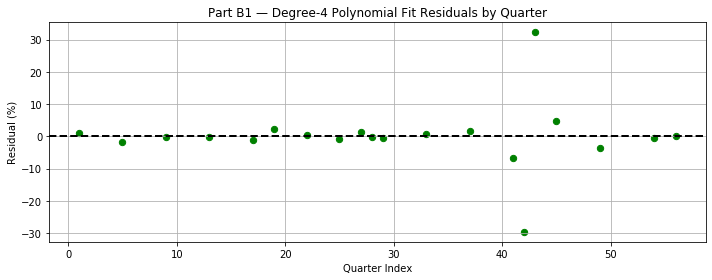

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(X_DATA, resid_poly, color='green', s=40)
ax.axhline(0, color='black', lw=2, ls='--')
ax.set_title('Part B1 — Degree-4 Polynomial Fit Residuals by Quarter')
ax.set_xlabel('Quarter Index')
ax.set_ylabel('Residual (%)')
ax.grid(True)
plt.tight_layout()
plt.show()

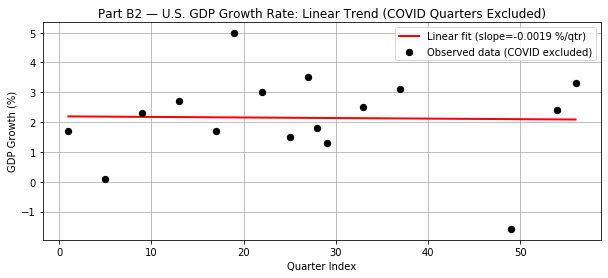

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(x_nc, y_nc, color='black', s=40, zorder=5, label='Observed data (COVID excluded)')
ax.plot(X_FULL, Y_lin_full, color='red', lw=2, label=f'Linear fit (slope={slope:.4f} %/qtr)')
ax.set_title('Part B2 — U.S. GDP Growth Rate: Linear Trend (COVID Quarters Excluded)')
ax.set_xlabel('Quarter Index')
ax.set_ylabel('GDP Growth (%)')
ax.legend()
ax.grid(True)
plt.show()

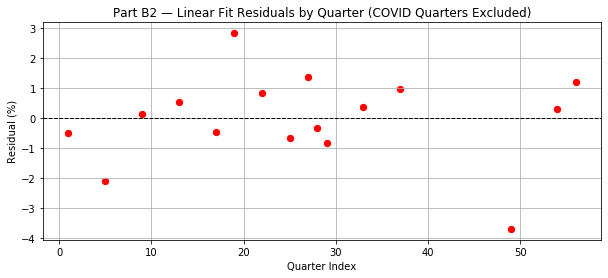

In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(x_nc, resid_lin, color='red', s=40)
ax.axhline(0, color='black', lw=1, ls='--')
ax.set_title('Part B2 — Linear Fit Residuals by Quarter (COVID Quarters Excluded)')
ax.set_xlabel('Quarter Index')
ax.set_ylabel('Residual (%)')
ax.grid(True)
plt.show()